# Transfer Learning

**Transfer Learning** is a machine learning technique where a model trained on one task is reused for a different but related task. Instead of training a neural network from scratch, we start with a **pre-trained model** that has already learned useful features from a large dataset.


### Why Does Transfer Learning Work?

Early layers of neural networks learn **general features**. In the case of images, this might be:
- Edges
- Colors

Later layers learn task-specific features. For example, given a classification dog versus cat task, later layers might learn:
- Length of snout
- Size of ears

If we remove a few of the last few layers that have this task-specific tuning, we still have a neural network with some tuning to the dataset of images. We can then repurpose this base model. A great analogy: a Romance language speaker might find it easy to learn another Romance language. The reason is because the Romance language speaker has learned the *underlying structure* of the Romance languages.



In [1]:
# preliminaries

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

dataset_path = tf.keras.utils.get_file(
    "flower_photos",
    "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz",
    untar=True
)

We'll pick a set to train on and a set to test on:

In [2]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 3670 files belonging to 1 classes.
Using 2936 files for training.
Found 3670 files belonging to 1 classes.
Using 734 files for validation.


Some pre-processing:

In [3]:
normalization_layer = tf.keras.layers.Rescaling(1.0 / 255)
train_dataset = train_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)
validation_dataset = validation_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.prefetch(AUTOTUNE)
validation_dataset = validation_dataset.prefetch(AUTOTUNE)

### The ImageNet Dataset & MobileNetV2

ImageNet contains:
- More than 14 million images
- Over 20,000 categories
- Approximately 1,000 commonly used classes for benchmarking

Examples include:

- Dogs
- Cats
- Birds
- Cars
- Flowers
- Fruits
- Buildings

From the 2018 paper [here](https://arxiv.org/abs/1801.04381), MobileNetV2 is a ImageNet-trained neural network available to us via `tensorflow`. We will take this neural network to be our base model that we will *not re-train*:

In [4]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False

We will add a few layers:


In [5]:
model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(12, activation="relu"),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(5, activation="softmax")  # 5 flower classes
])

In [6]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 12)             │        15,372 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,273,421 (8.67 MB)

 Trainable params: 15,437 (60.30 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Note that we have almost 2.3 _million_ parameters in total here. But, only 15 _thousand_ of them will be trained. One can imagine the computational savings... Let's compile:

In [7]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

By only training these 15 thousand parameters, we still get _exceptional_ accuracy for our dataset _while_ saving time and computation:

c:\Users\garre\miniconda3\envs\jbook\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


23/23 ━━━━━━━━━━━━━━━━━━━━ 18s 772ms/step - accuracy: 1.0000 - loss: 5.6669e-06
Validation Accuracy: 1.0000


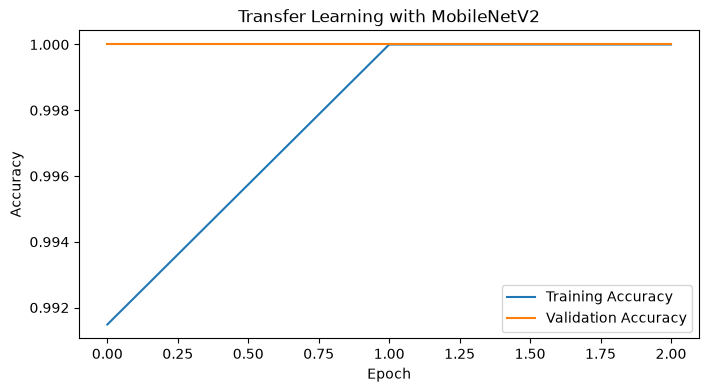

In [8]:
network = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=3,
    verbose=False
)
loss, accuracy = model.evaluate(validation_dataset)
print(f"Validation Accuracy: {accuracy:.4f}")


plt.figure(figsize=(8, 4))
plt.plot(network.history["accuracy"], label="Training Accuracy")
plt.plot(network.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Transfer Learning with MobileNetV2")
plt.legend()
plt.show()

### Lab Problems

---

1. Using the model from class, replace MobileNetV2 with ResNet50.

Evaluate:

- Training time
- Accuracy
- Model size

---

2. Create a transfer learning model using the TensorFlow Flowers dataset and classify five flower species.

### Lab Key*

---

1.

---

2.

Note that sample code was taken and adjusted from TensorFlow documentation: [link here](https://www.tensorflow.org/tutorials/images).